In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
print(df.head())
print(df.info())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(8807, 12)


In [5]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [6]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [7]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [8]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


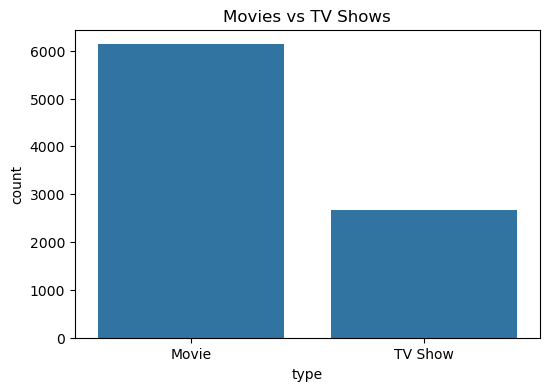

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")
plt.show()

In [13]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed',
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

In [14]:
content_year = df['year_added'].value_counts().sort_index()

print(content_year)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


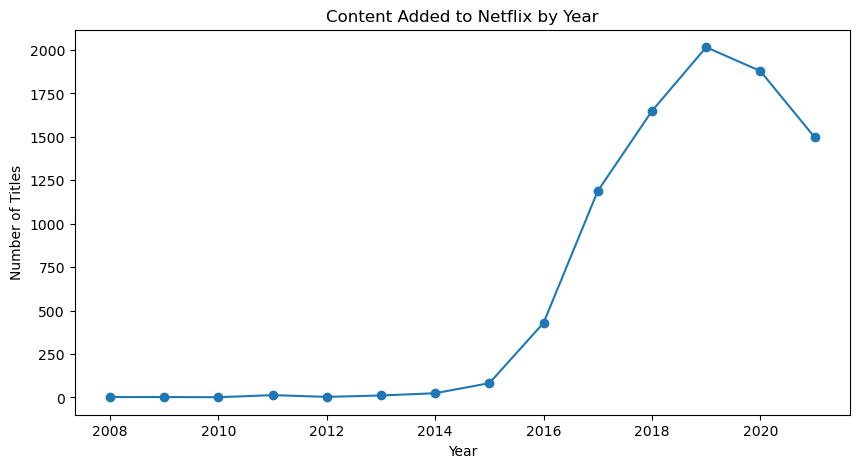

In [15]:
plt.figure(figsize=(10,5))

content_year.plot(kind='line', marker='o')
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

In [16]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


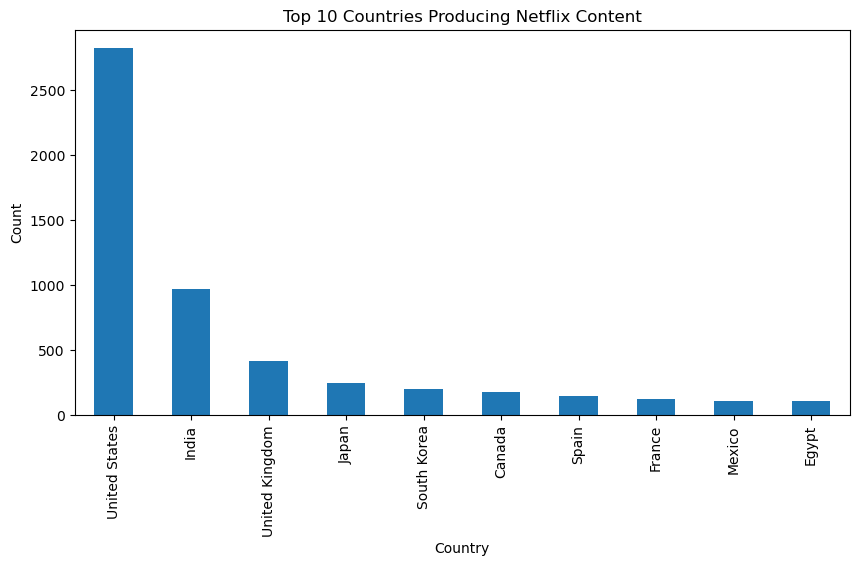

In [17]:
plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

In [18]:
rating_count = df['rating'].value_counts()

print(rating_count)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


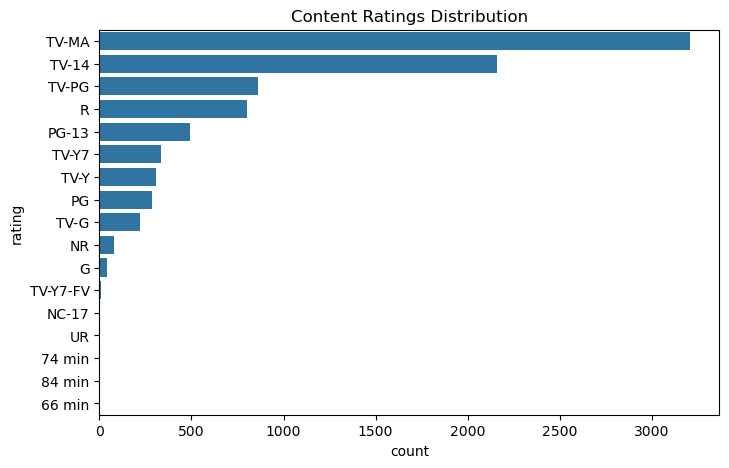

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")

plt.show()

In [20]:
numeric_df = df.select_dtypes(include=['int64','float64'])

print(numeric_df.corr())

              release_year  year_added
release_year      1.000000    0.111531
year_added        0.111531    1.000000


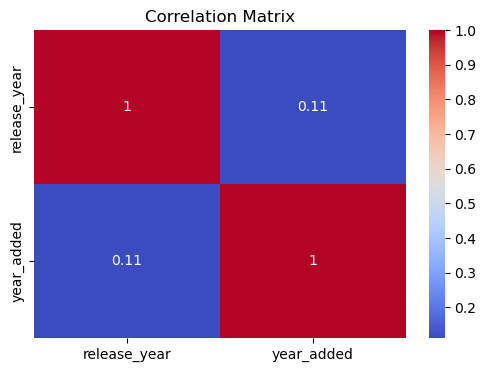

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")

plt.show()

In [22]:
release_trend = df['release_year'].value_counts().sort_index()

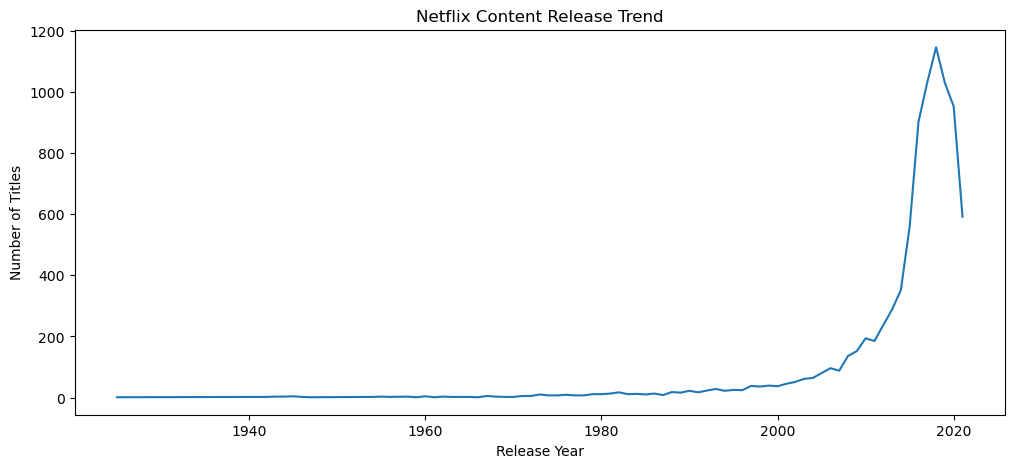

In [23]:
plt.figure(figsize=(12,5))

release_trend.plot()
plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()